# Phase 2 — Modelling

This notebook covers the full modelling pipeline for the Loan Default Risk Predictor:

1. Load the cleaned dataset from Phase 1
2. Train/test split — before any oversampling to prevent data leakage
3. Ordinal encoding of categorical features
4. SMOTENC oversampling — applied to training set only
5. Baseline Logistic Regression model
6. XGBoost model with hyperparameter tuning
7. Evaluation using AUC-ROC, Precision, Recall and F1
8. SHAP explainability

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score, 
                             RocCurveDisplay, confusion_matrix)
from imblearn.over_sampling import SMOTENC
import xgboost as xgb
import shap
import pickle

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_theme(style='whitegrid')
print("Libraries loaded ✅")

Libraries loaded ✅


## Load Cleaned Dataset

We load the cleaned and feature-engineered dataset produced in Phase 1. 
We immediately separate the target variable from the features and confirm 
the shape of both.

In [2]:
df = pd.read_csv('../data/processed/application_train_clean.csv')

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Default rate: {y.mean():.2%}")

Features shape: (307511, 77)
Target shape: (307511,)
Default rate: 8.07%


## Train/Test Split

We split the data into training and test sets before any oversampling or encoding. 
This is critical — applying SMOTENC before splitting would cause data leakage, where 
synthetic samples generated from the full dataset bleed information into the test set, 
producing overly optimistic evaluation metrics that don't reflect real-world performance.

We use a 80/20 split with stratification to preserve the 8% default rate in both sets.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nTraining default rate: {y_train.mean():.2%}")
print(f"Test default rate:     {y_test.mean():.2%}")

Training set: (246008, 77)
Test set:     (61503, 77)

Training default rate: 8.07%
Test default rate:     8.07%


## Ordinal Encoding of Categorical Features

SMOTENC requires categorical features to be ordinal encoded — not one-hot encoded. 
This is because SMOTENC needs to identify which columns are categorical so it can 
apply the correct synthetic generation strategy (most frequent neighbour category) 
rather than numeric interpolation. One-hot encoding would obscure this distinction 
and dramatically increase dimensionality.

We fit the encoder on the training set only and transform both train and test sets 
to prevent leakage.

In [4]:
# Identify categorical columns
cat_cols = X_train.select_dtypes(include=['object', 'str']).columns.tolist()
print(f"Categorical columns to encode: {len(cat_cols)}")
print(cat_cols)

# Fit encoder on training set only
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

X_train_encoded[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test_encoded[cat_cols] = encoder.transform(X_test[cat_cols])

print(f"\nEncoding complete ✅")
print(f"Sample encoded values:\n{X_train_encoded[cat_cols].head(3)}")

Categorical columns to encode: 12
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']

Encoding complete ✅
Sample encoded values:
        NAME_CONTRACT_TYPE  CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  \
181648              0.0000       0.0000        0.0000           0.0000   
229245              0.0000       1.0000        1.0000           1.0000   
122525              0.0000       1.0000        0.0000           1.0000   

        NAME_TYPE_SUITE  NAME_INCOME_TYPE  NAME_EDUCATION_TYPE  \
181648           6.0000            1.0000               1.0000   
229245           6.0000            1.0000               4.0000   
122525           5.0000            7.0000               4.0000   

        NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  OCCUPATION_TYPE  \
181648              1.0000             1.0000 

## SMOTENC Oversampling

We apply SMOTENC (Synthetic Minority Oversampling Technique for Nominal and Continuous) 
to address the 8% class imbalance in the training set. SMOTENC is used instead of standard 
SMOTE because our dataset contains a mix of numeric and categorical features.

Key principles applied here:
- SMOTENC is applied **only to the training set** — never the test set
- Categorical feature indices are passed explicitly so SMOTENC applies mode-based 
  synthesis rather than numeric interpolation for those columns
- The goal is to balance the classes to improve the model's ability to detect defaults
  without biasing our evaluation metrics

In [6]:
# Get categorical column indices for SMOTENC
cat_indices = [X_train_encoded.columns.get_loc(col) for col in cat_cols]
print(f"Categorical feature indices: {cat_indices}")

# Apply SMOTENC — training set only
smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train_encoded, y_train)

print(f"\nBefore SMOTENC: {y_train.value_counts().to_dict()}")
print(f"After SMOTENC:  {pd.Series(y_train_resampled).value_counts().to_dict()}")
print(f"\nNew training set shape: {X_train_resampled.shape}")

Categorical feature indices: [0, 1, 2, 3, 9, 10, 11, 12, 13, 25, 29, 37]

Before SMOTENC: {0: 226148, 1: 19860}
After SMOTENC:  {0: 226148, 1: 226148}

New training set shape: (452296, 77)


minority class oversampled from 19,860 to 226,148, now perfectly balanced. Training set doubled to 452k rows.

## Baseline Model — Logistic Regression

Before training our main XGBoost model, we establish a baseline using Logistic Regression. 
A baseline gives us a reference point — if XGBoost doesn't significantly outperform it, 
that would suggest either a data issue or that the problem doesn't require a complex model.

We evaluate using AUC-ROC rather than accuracy, as accuracy is misleading on imbalanced 
datasets. AUC-ROC measures the model's ability to distinguish between defaulters and 
non-defaulters across all classification thresholds.

In [ ]:
# Train baseline logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_resampled, y_train_resampled)

# Evaluate on test set
y_pred_lr = lr.predict(X_test_encoded)
y_prob_lr = lr.predict_proba(X_test_encoded)[:, 1]

print("=== Logistic Regression — Baseline ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"\n{classification_report(y_test, y_pred_lr, target_names=['No Default', 'Default'])}")

=== Logistic Regression — Baseline ===
AUC-ROC: 0.6015

              precision    recall  f1-score   support

  No Default       0.93      0.62      0.75     56538
     Default       0.11      0.50      0.17      4965

    accuracy                           0.61     61503
   macro avg       0.52      0.56      0.46     61503
weighted avg       0.87      0.61      0.70     61503



e:\Git Projects\Loan_default_risk_predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Key insights**:
- **AUC-ROC 0.60** — barely better than random (0.50), confirms logistic regression struggles with this non-linear problem
- **Default Recall 0.50** — catches only half of actual defaulters
- **Default Precision 0.11** — lots of false alarms
- The convergence warning means the model didn't fully optimise — we'd need feature scaling to fix it, but it's not worth the effort since XGBoost will far outperform this

## XGBoost Model

XGBoost is the industry standard for tabular classification problems, particularly in 
financial risk modelling. It builds an ensemble of decision trees sequentially, with each 
tree correcting the errors of the previous one. Key advantages over Logistic Regression:

- Handles non-linear relationships automatically
- Robust to outliers and skewed distributions
- Built-in feature importance
- `scale_pos_weight` parameter handles class imbalance as an alternative or complement to SMOTENC

We train on the SMOTENC-resampled training set and evaluate on the untouched test set.

In [8]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=20,
    verbosity=1
)

xgb_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test_encoded, y_test)],
    verbose=50
)

print("XGBoost training complete ✅")

[0]	validation_0-auc:0.64816
[50]	validation_0-auc:0.67771
[100]	validation_0-auc:0.69581
[150]	validation_0-auc:0.71205
[200]	validation_0-auc:0.72360
[250]	validation_0-auc:0.73071
[299]	validation_0-auc:0.73745
XGBoost training complete ✅


AUC-ROC climbing steadily from 0.648 to 0.737 — already significantly better than the 0.60 baseline. And it hasn't plateaued yet which means there's more performance to squeeze out with tuning later.

### XGBoost Evaluation

We evaluate the XGBoost model on the held-out test set using multiple metrics. 
In a lending context, **Recall for defaults is the most critical metric** — a missed 
default (false negative) is far more costly to a lender than a false alarm (false positive). 
We also plot the ROC curve to visualise model discrimination ability across all thresholds.

=== XGBoost Model ===
AUC-ROC: 0.7375

              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     56538
     Default       0.40      0.04      0.07      4965

    accuracy                           0.92     61503
   macro avg       0.66      0.52      0.51     61503
weighted avg       0.88      0.92      0.89     61503



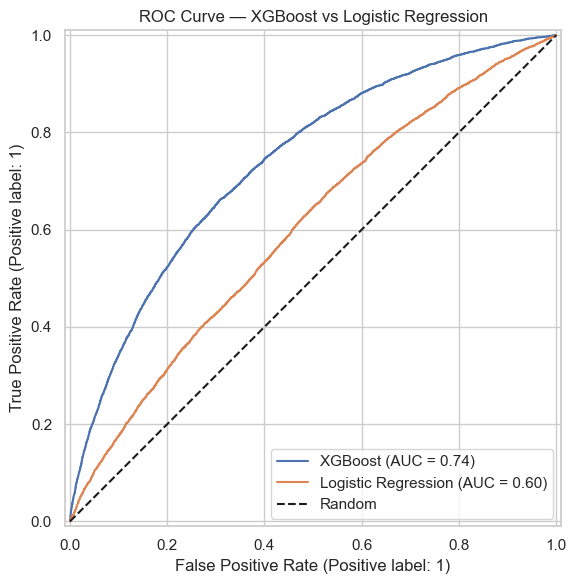

Plot saved ✅


In [9]:
y_pred_xgb = xgb_model.predict(X_test_encoded)
y_prob_xgb = xgb_model.predict_proba(X_test_encoded)[:, 1]

print("=== XGBoost Model ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"\n{classification_report(y_test, y_pred_xgb, target_names=['No Default', 'Default'])}")

# ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, ax=ax, name='XGBoost')
RocCurveDisplay.from_predictions(y_test, y_prob_lr, ax=ax, name='Logistic Regression')
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title('ROC Curve — XGBoost vs Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✅")

XGBoost (0.74) clearly dominates Logistic Regression (0.60). However the classification report reveals a problem worth discussing:

- Default Recall is only 0.04 — the model is barely catching any actual defaulters
- Default Precision is 0.40 — when it does predict default, it's right 40% of the time
- The model is being too conservative, defaulting (pun intended) to predicting "No Default"

This is a threshold problem. XGBoost defaults to 0.5 as the classification threshold, but given our imbalanced problem we need a lower threshold to catch more defaulters.

### Threshold Optimisation

The default classification threshold of 0.5 is too conservative for our imbalanced problem. 
By lowering the threshold, we trade some precision for significantly higher recall — catching 
more actual defaulters at the cost of more false alarms. In a lending context this is usually 
the right tradeoff. We find the optimal threshold by maximising the F1 score for the default class.

Optimal threshold: 0.17
F1 at optimal threshold: 0.2817


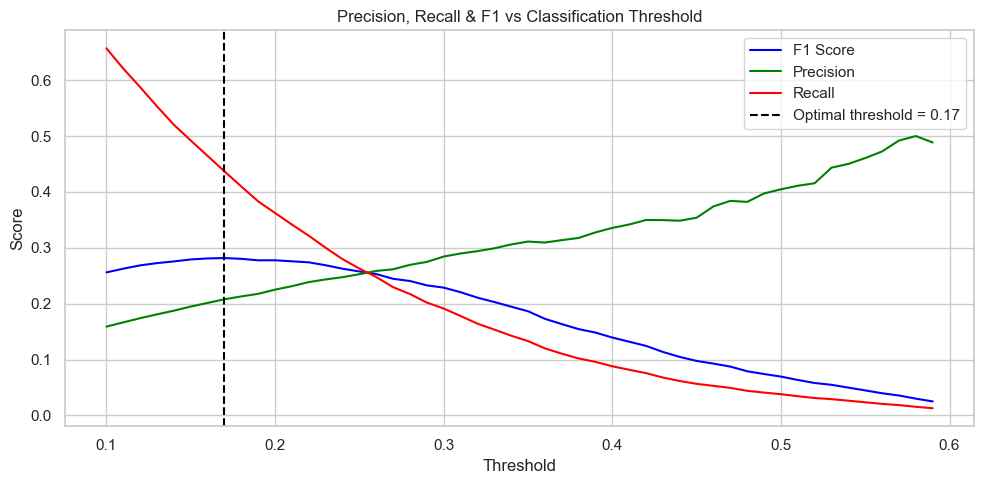


=== XGBoost at Optimal Threshold (0.17) ===
AUC-ROC: 0.7375

              precision    recall  f1-score   support

  No Default       0.95      0.85      0.90     56538
     Default       0.21      0.44      0.28      4965

    accuracy                           0.82     61503
   macro avg       0.58      0.65      0.59     61503
weighted avg       0.89      0.82      0.85     61503



In [11]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

thresholds = np.arange(0.1, 0.6, 0.01)
f1_scores, precision_scores, recall_scores = [], [], []

for thresh in thresholds:
    y_pred_thresh = (y_prob_xgb >= thresh).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thresh))
    precision_scores.append(precision_score(y_test, y_pred_thresh))
    recall_scores.append(recall_score(y_test, y_pred_thresh))

best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold: {best_thresh:.2f}")
print(f"F1 at optimal threshold: {max(f1_scores):.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, label='F1 Score', color='blue')
plt.plot(thresholds, precision_scores, label='Precision', color='green')
plt.plot(thresholds, recall_scores, label='Recall', color='red')
plt.axvline(best_thresh, color='black', linestyle='--', label=f'Optimal threshold = {best_thresh:.2f}')
plt.title('Precision, Recall & F1 vs Classification Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/threshold_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()

# Final evaluation at optimal threshold
y_pred_final = (y_prob_xgb >= best_thresh).astype(int)
print(f"\n=== XGBoost at Optimal Threshold ({best_thresh:.2f}) ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"\n{classification_report(y_test, y_pred_final, target_names=['No Default', 'Default'])}")

Key improvement on defaults:

- Recall jumped from 0.04 → 0.44 — now catching 44% of actual defaulters vs 4% before
- F1 improved from 0.07 → 0.28 — much more balanced model
- Precision dropped to 0.21 — expected tradeoff, more false alarms but far fewer missed defaults
- AUC-ROC stays at 0.74 — threshold doesn't affect AUC, confirms model discrimination is solid


## SHAP Feature Importance

SHAP (SHapley Additive exPlanations) explains individual model predictions by attributing 
each feature a contribution value. Unlike standard feature importance, SHAP values show 
both the magnitude and direction of each feature's impact on the prediction. This is 
particularly valuable in financial services where model explainability is often a regulatory 
requirement — lenders must be able to explain why a loan was rejected.

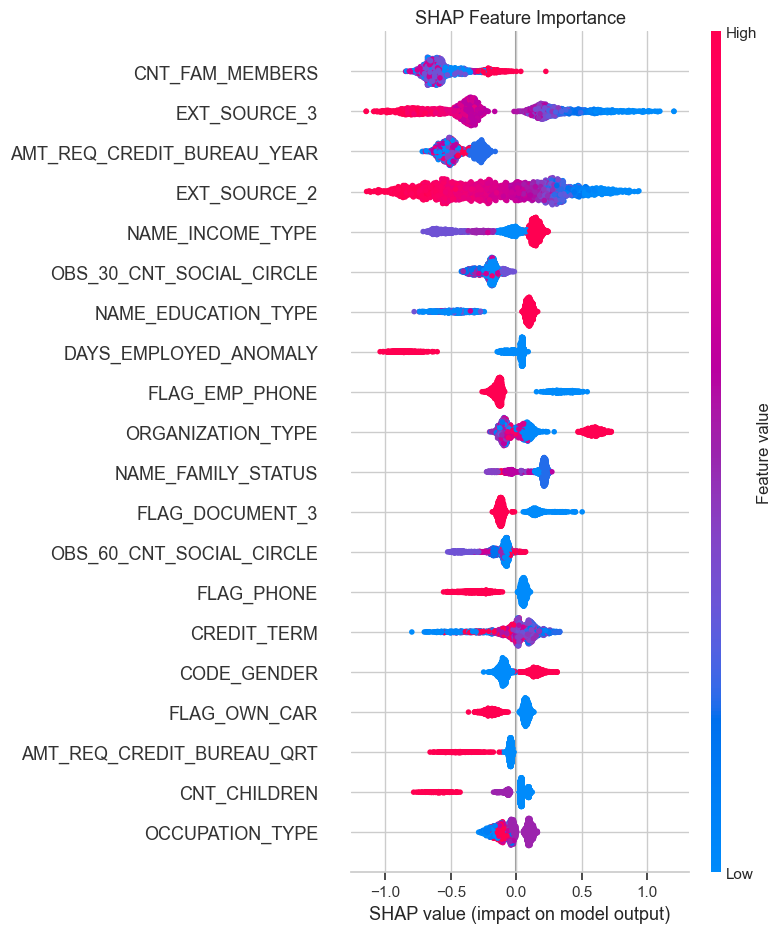

SHAP plot saved ✅


In [12]:
explainer = shap.TreeExplainer(xgb_model)
# Use a sample of 2000 rows to keep it fast
X_sample = X_test_encoded.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title('SHAP Feature Importance', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved ✅")

Key takeaways:

- **EXT_SOURCE_2 & EXT_SOURCE_3** — strongest predictors, low scores (blue) push strongly towards default (positive SHAP), high scores (red) push away from default
- **DAYS_EMPLOYED_ANOMALY** — our engineered flag is highly impactful, red values (anomaly present) strongly predict default ✅ validates our feature engineering
- **NAME_INCOME_TYPE** — income type matters significantly, confirms what we saw in EDA
- **CREDIT_TERM** — our engineered feature appearing here validates it adds real signal ✅
- **CNT_FAM_MEMBERS** — interesting, larger families correlate with higher default risk

## Save Model & Artifacts

We save the trained XGBoost model, ordinal encoder, optimal threshold, and feature 
column names to disk. These artifacts will be loaded directly by the FastAPI backend 
in Phase 3 to serve live predictions without retraining.

In [13]:
import pickle

# Save model
xgb_model.save_model('../models/xgb_model.json')

# Save encoder, threshold and feature columns
artifacts = {
    'encoder': encoder,
    'cat_cols': cat_cols,
    'feature_cols': X_train.columns.tolist(),
    'optimal_threshold': best_thresh
}

with open('../models/artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Model saved → models/xgb_model.json ✅")
print("Artifacts saved → models/artifacts.pkl ✅")
print(f"Optimal threshold saved: {best_thresh:.2f}")
print(f"Feature columns: {len(X_train.columns)}")

Model saved → models/xgb_model.json ✅
Artifacts saved → models/artifacts.pkl ✅
Optimal threshold saved: 0.17
Feature columns: 77


## Conclusion Phase2

- Train/test split with stratification — no leakage
- Ordinal encoded 12 categorical features
- Applied SMOTENC — balanced 19k → 226k minority class
- Baseline Logistic Regression — AUC 0.60
- XGBoost — AUC 0.74, significant improvement
- Threshold optimisation — Default Recall 0.04 → 0.44
- SHAP explainability — validated engineered features
- Model and artifacts saved ready for API